In [49]:
print("AI Resume Screening & Skill Extraction System")
print("Developed by: Sanchit Madane")

AI Resume Screening & Skill Extraction System
Developed by: Sanchit Madane


In [50]:
job_description = """We are looking for a Data Analyst with strong skills in Python, SQL, data analysis, statistics, and machine learning.
Experience with Pandas, NumPy, and data visualization is preferred."""

In [51]:
resumes = [
"Python developer with experience in machine learning, pandas, SQL, numpy, and data analysis projects.",
"Data analyst skilled in SQL, Power BI, statistics, and business analytics.",
"Machine learning enthusiast with Python, scikit-learn, and predictive modeling experience.",
"Web developer experienced in HTML, CSS, JavaScript, and frontend frameworks.",
"AI and data science student with knowledge of Python, machine learning, pandas, numpy, and data visualization."]

In [52]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("AI Resume Screening System - Sanchit Madane")

documents = [job_description] + resumes

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=1000,
    min_df = 1)

vectors = vectorizer.fit_transform(documents)

similarity = cosine_similarity(vectors[0:1], vectors[1:]).flatten()

similarity = (similarity - similarity.min()) / (similarity.max() - similarity.min())

results = pd.DataFrame({
    "Candidate": ["Resume 1","Resume 2","Resume 3","Resume 4","Resume 5"],
    "Match Score": similarity})

results = results.sort_values(by="Match Score", ascending=False)

results

AI Resume Screening System - Sanchit Madane


,Candidate,Match Score
4,Resume 5,1.000000
0,Resume 1,0.984131
1,Resume 2,0.544071
2,Resume 3,0.298858
3,Resume 4,0.000000


In [53]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
job_vector = vectors[0].toarray().flatten()

top_indices = job_vector.argsort()[-8:][::-1]

skill_keywords = [
    "python","sql","machine learning","data analysis",
    "statistics","pandas","numpy","data visualization",
    "power bi","excel","scikit learn"]

job_text = job_description.lower()

extracted_skills = []

for skill in skill_keywords:
    if skill in job_text:
        extracted_skills.append(skill)

print("Top Skills Required for Job:\n")
print(extracted_skills)

Top Skills Required for Job:

['python', 'sql', 'machine learning', 'data analysis', 'statistics', 'pandas', 'numpy', 'data visualization']


In [54]:
best_candidate = results.iloc[0]

print("\nRecommended Candidate for the Job:")
print(best_candidate["Candidate"])
print("Match Score:", round(best_candidate["Match Score"],3))


Recommended Candidate for the Job:
Resume 5
Match Score: 1.0


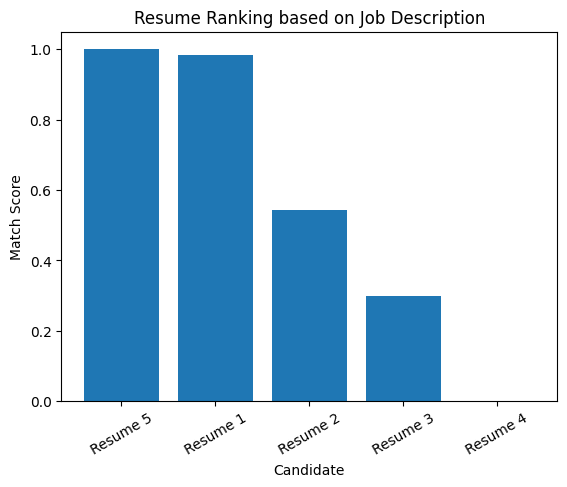

In [55]:
import matplotlib.pyplot as plt

plt.bar(results["Candidate"], results["Match Score"])
plt.xlabel("Candidate")
plt.ylabel("Match Score")
plt.title("Resume Ranking based on Job Description")
plt.xticks(rotation=30)
plt.show()